addicted_label이 0에서 1로 바뀔 때, 사용자의 행동 데이터는 어떻게 달라지는가?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["axes.unicode_minus"] = False

In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

train.shape, test.shape

((691369, 14), (296302, 13))

#### 데이터 기본 구조
이 데이터를 있는 그대로 믿어도 되는가? 

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [4]:
id_dup = train["id"].duplicated().sum()
row_dup = train.duplicated().sum()

id_dup, row_dup

(0, 0)

#### 결측치 분석
가설 : 결측 여부 자체가 addictied_label과 관련이 있은 수 있다

- 컬럼별 결측률
- target 그룹별 결측률 차이
- 한 사용자가 여러 칼럼에서 동시에 결측인 경우가 있는지 여부

In [5]:
num_cols = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time",
]
cat_cols = ["gender", "stress_level", "academic_work_impact"]

rows = []
for col in num_cols + cat_cols:
    miss0 = train.loc[train["addicted_label"] == 0, col].isna().mean() * 100
    miss1 = train.loc[train["addicted_label"] == 1, col].isna().mean() * 100
    rows.append({"column": col, "label0_missing_pct": round(miss0, 2),
                 "label1_missing_pct": round(miss1, 2), "diff": round(miss1 - miss0, 2)})

missing_by_target = pd.DataFrame(rows).sort_values("diff", key=abs, ascending=False)
missing_by_target

,column,label0_missing_pct,label1_missing_pct,diff
7,app_opens_per_day,11.54,11.73,0.19
1,daily_screen_time_hours,13.77,13.90,0.13
5,sleep_hours,6.35,6.47,0.12
3,gaming_hours,18.28,18.37,0.10
8,weekend_screen_time,16.14,16.24,0.10
0,age,4.13,4.21,0.08
4,work_study_hours,7.42,7.46,0.04
6,notifications_per_day,9.75,9.79,0.04
10,stress_level,7.99,7.97,-0.02
9,gender,4.21,4.20,-0.01


두 그룹 간 결측률 차이가 0.2%p를 넘지 않는다. 처음 가설은 데이터에서 기각됨 

In [6]:
miss_count = train[num_cols + cat_cols].isna().sum(axis=1)

pd.DataFrame({
    "missing_count": miss_count,
    "addicted_label": train["addicted_label"]
}).groupby("missing_count")["addicted_label"].agg(["mean", "count"])

,mean,count
missing_count,,
0,0.708123,269185
1,0.708970,180459
2,0.711178,120697
3,0.711784,67328
4,0.709494,32557
5,0.712458,13678
6,0.719217,5157
7,0.696301,1676
8,0.702306,477


#### Target 분포

In [7]:
target_ratio = train["addicted_label"].value_counts(normalize=True).round(4)
target_ratio

addicted_label
1    0.7094
0    0.2906
Name: proportion, dtype: float64

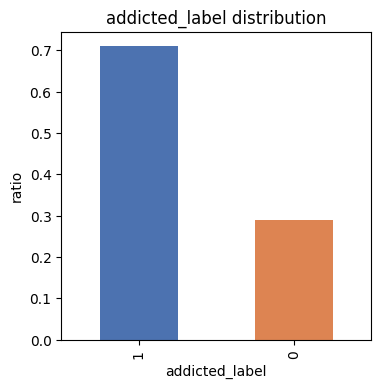

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
target_ratio.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("addicted_label distribution")
ax.set_xlabel("addicted_label")
ax.set_ylabel("ratio")
plt.show()

1(중독군)이 약 71%, 0(비중독군)이 약 29%

어느 정도 불균형이 있어서 CV는 Stratified K-Fold로 고정

평가지표는 ROC-AUC를 기준으로 함

#### 수치형 변수와 Target 관계

In [9]:
train.groupby("addicted_label")[num_cols].mean().T.round(3)

addicted_label,0,1
age,26.583,26.629
daily_screen_time_hours,5.043,8.707
social_media_hours,1.376,2.919
gaming_hours,1.160,1.582
work_study_hours,1.873,2.570
sleep_hours,6.722,6.838
notifications_per_day,147.088,145.406
app_opens_per_day,97.871,104.593
weekend_screen_time,6.849,10.559


In [10]:
corr_with_target = train[num_cols + ["addicted_label"]].corr()["addicted_label"]
corr_with_target.drop("addicted_label").sort_values(ascending=False)

daily_screen_time_hours    0.611398
weekend_screen_time        0.589903
social_media_hours         0.532409
work_study_hours           0.251416
gaming_hours               0.205283
app_opens_per_day          0.063482
sleep_hours                0.042545
age                        0.004043
notifications_per_day     -0.011583
Name: addicted_label, dtype: float64

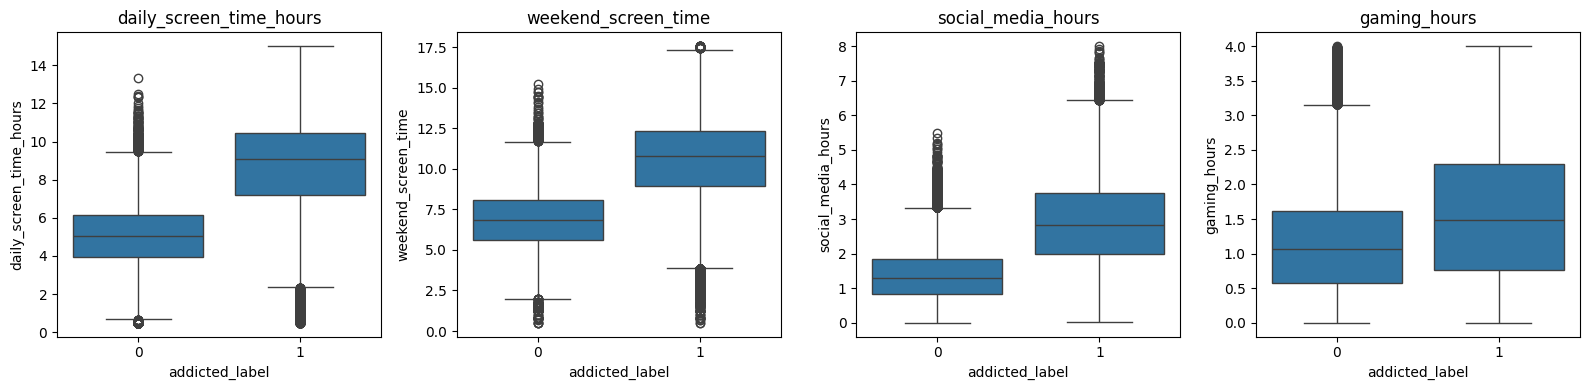

In [11]:
top_features = ["daily_screen_time_hours", "weekend_screen_time", "social_media_hours", "gaming_hours"]

fig, axes = plt.subplots(1, len(top_features), figsize=(16, 4))
for ax, col in zip(axes, top_features):
    sns.boxplot(data=train, x="addicted_label", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### 범주형 변수와 Target 관계

In [12]:
for col in cat_cols:
    print(col)
    result = train.groupby(col)["addicted_label"].agg(["mean", "count"]).round(4)
    print(result)

gender
          mean   count
gender                
Female  0.7038  221595
Male    0.7232  223662
Other   0.7010  217078
stress_level
                mean   count
stress_level                
High          0.7114  220873
Low           0.7112  207783
Medium        0.7057  207565
academic_work_impact
                        mean   count
academic_work_impact                
No                    0.7110  316579
Yes                   0.7079  330566


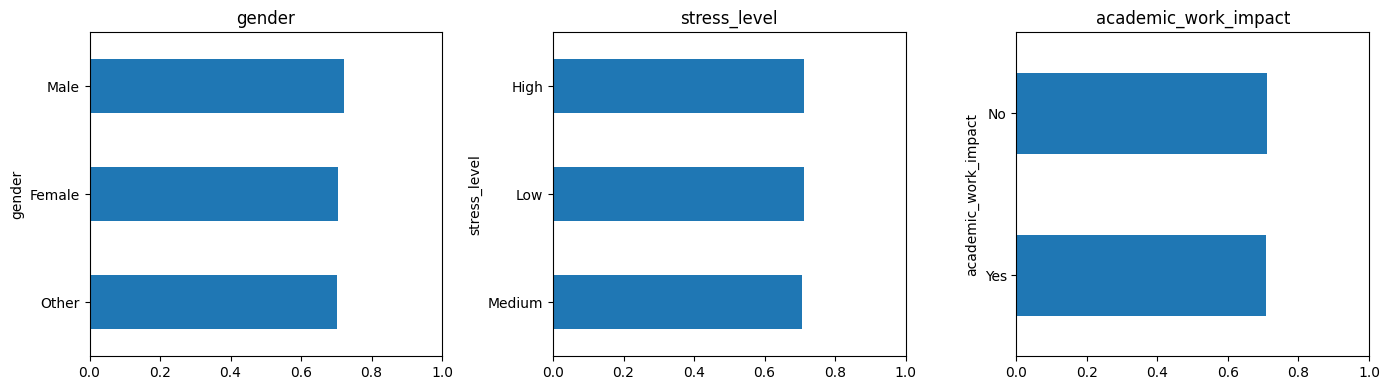

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    rates = train.groupby(col)["addicted_label"].mean().sort_values()
    rates.plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

#### 변수 사이 상관관계

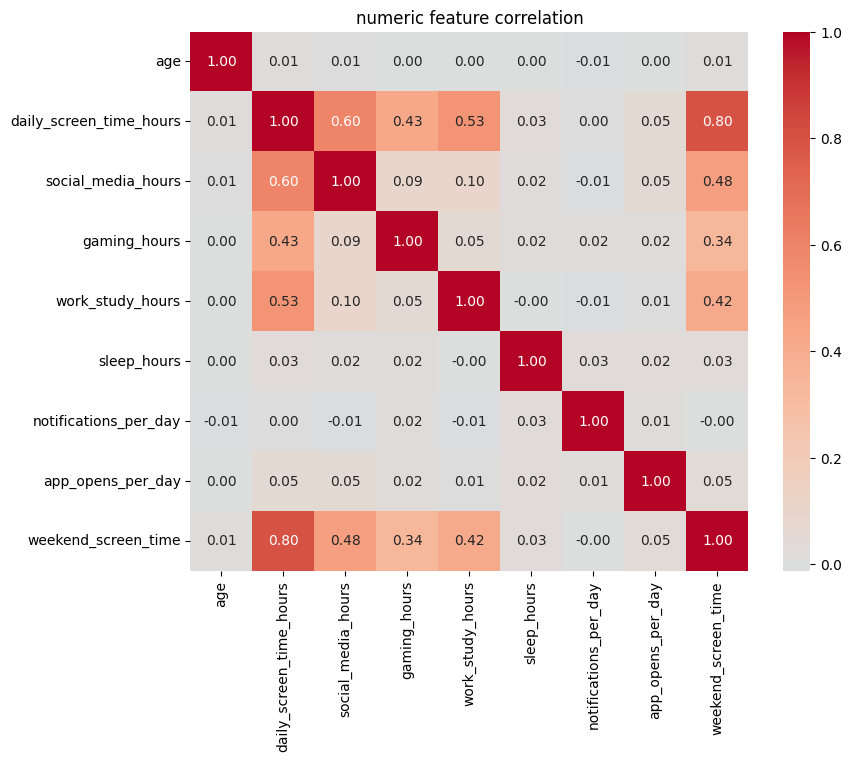

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(train[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("numeric feature correlation")
plt.show()